# NovaCart One-Click Checkout - A/B Test Analysis

**Scenario (original, invented for this project):** NovaCart, a fictional
online store, tested a new **One-Click Express Checkout** button against its
existing multi-step checkout flow.

- **Group A = Control** (old multi-step checkout)
- **Group B = Treatment** (new one-click checkout)

This notebook walks through the entire analysis end-to-end:

1. Generate a synthetic dataset (20,000 sessions)
2. Load it into a SQL database and run analysis queries
3. Run statistical significance tests (two-proportion z-test, t-test)
4. Visualize the results
5. State the final recommendation

Every dataset value here is randomly generated in this notebook - no
external or copied data is used, so this notebook and its outputs are
original work.


## 1. Setup - import libraries

In [1]:
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from scipy import stats
from datetime import datetime, timedelta

np.random.seed(42)
pd.set_option("display.max_columns", None)


## 2. Generate the synthetic dataset

We simulate 20,000 independent checkout sessions split ~50/50 between
Control (A) and Treatment (B). A deliberate treatment effect is built in
(+2.1 percentage points base conversion lift, extra lift on mobile, slightly
higher average order value, and faster checkout time) so the test has a
real, discoverable signal — just like a real experiment would.

In [2]:
N_USERS = 20000
START_DATE = datetime(2026, 6, 1)
TEST_DAYS = 21

devices = ["mobile", "desktop", "tablet"]
device_probs = [0.58, 0.35, 0.07]

countries = ["IN", "US", "UK", "DE", "AE", "SG"]
country_probs = [0.40, 0.25, 0.10, 0.10, 0.08, 0.07]

traffic_sources = ["organic", "paid_search", "social", "email", "direct"]
traffic_probs = [0.35, 0.25, 0.15, 0.10, 0.15]

rows = []
user_id_start = 100000

for i in range(N_USERS):
    user_id = user_id_start + i
    group = np.random.choice(["A", "B"], p=[0.5, 0.5])

    session_day = np.random.randint(0, TEST_DAYS)
    session_date = START_DATE + timedelta(days=int(session_day))
    session_hour = np.random.randint(0, 24)
    timestamp = session_date + timedelta(hours=int(session_hour),
                                          minutes=int(np.random.randint(0, 60)))

    device = np.random.choice(devices, p=device_probs)
    country = np.random.choice(countries, p=country_probs)
    traffic_source = np.random.choice(traffic_sources, p=traffic_probs)
    new_visitor = np.random.choice([1, 0], p=[0.62, 0.38])

    base_conv = 0.112
    device_adj = {"mobile": -0.010, "desktop": 0.020, "tablet": -0.005}[device]
    visitor_adj = -0.018 if new_visitor else 0.014
    traffic_adj = {
        "organic": 0.005, "paid_search": -0.006, "social": -0.012,
        "email": 0.022, "direct": 0.010
    }[traffic_source]

    conv_prob = base_conv + device_adj + visitor_adj + traffic_adj

    if group == "B":
        conv_prob += 0.021
        if device == "mobile":
            conv_prob += 0.010

    conv_prob = float(np.clip(conv_prob, 0.01, 0.95))
    converted = np.random.binomial(1, conv_prob)

    if converted:
        base_aov = np.random.normal(loc=54.0, scale=18.0)
        if group == "B":
            base_aov += 1.8
        order_value = round(max(base_aov, 8.0), 2)
        items_in_cart = np.random.randint(1, 6)
    else:
        order_value = 0.0
        items_in_cart = np.random.randint(0, 4)

    added_to_cart = 1 if (items_in_cart > 0 or converted) else 0
    abandoned_cart = 1 if (added_to_cart and not converted) else 0

    checkout_time = np.random.normal(loc=95, scale=25) if group == "A" else np.random.normal(loc=58, scale=18)
    checkout_time = round(max(checkout_time, 8), 1)

    rows.append({
        "user_id": user_id,
        "session_timestamp": timestamp.strftime("%Y-%m-%d %H:%M:%S"),
        "test_group": group,
        "device_type": device,
        "country": country,
        "traffic_source": traffic_source,
        "new_visitor": new_visitor,
        "added_to_cart": added_to_cart,
        "checkout_time_seconds": checkout_time,
        "converted": converted,
        "order_value_usd": order_value,
        "items_in_cart": items_in_cart,
        "abandoned_cart": abandoned_cart,
    })

df = pd.DataFrame(rows)
df.sort_values("session_timestamp", inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Generated {len(df):,} sessions")
df.head()


Generated 20,000 sessions


,user_id,session_timestamp,test_group,device_type,country,traffic_source,new_visitor,added_to_cart,checkout_time_seconds,converted,order_value_usd,items_in_cart,abandoned_cart
0,105291,2026-06-01 00:00:00,A,mobile,IN,direct,0,1,95.0,0,0.0,2,1
1,106503,2026-06-01 00:02:00,A,mobile,IN,direct,0,1,104.4,0,0.0,1,1
2,107490,2026-06-01 00:02:00,B,tablet,IN,organic,1,0,44.1,0,0.0,0,0
3,101060,2026-06-01 00:04:00,B,desktop,US,social,0,1,42.4,0,0.0,1,1
4,109627,2026-06-01 00:04:00,B,desktop,IN,organic,1,1,18.9,0,0.0,3,1


In [3]:
# Save to CSV so it matches the rest of the project (data/, sql/, excel/ folders)
import os
os.makedirs("../data", exist_ok=True)
df.to_csv("../data/ab_test_sessions.csv", index=False)
print("Saved to ../data/ab_test_sessions.csv")


Saved to ../data/ab_test_sessions.csv


## 3. Load into SQL (SQLite) and run analysis queries

We load the dataframe into an in-memory-style SQLite database and run the
same queries found in `sql/01_analysis_queries.sql`.

In [4]:
conn = sqlite3.connect("../data/novacart_ab_test.db")
df.to_sql("ab_test_sessions", conn, if_exists="replace", index=False)
print("Loaded into SQLite table ab_test_sessions")


Loaded into SQLite table ab_test_sessions


In [5]:
# Query 1: Conversion rate by group
q1 = '''
SELECT
    test_group,
    COUNT(*) AS total_sessions,
    SUM(converted) AS total_conversions,
    ROUND(100.0 * SUM(converted) / COUNT(*), 2) AS conversion_rate_pct
FROM ab_test_sessions
GROUP BY test_group
ORDER BY test_group;
'''
pd.read_sql(q1, conn)


,test_group,total_sessions,total_conversions,conversion_rate_pct
0,A,9876,1055,10.68
1,B,10124,1325,13.09


In [6]:
# Query 2: Average order value (AOV) -- converted sessions only
q2 = '''
SELECT
    test_group,
    COUNT(*) AS orders,
    ROUND(AVG(order_value_usd), 2) AS avg_order_value_usd,
    ROUND(SUM(order_value_usd), 2) AS total_revenue_usd
FROM ab_test_sessions
WHERE converted = 1
GROUP BY test_group
ORDER BY test_group;
'''
pd.read_sql(q2, conn)


,test_group,orders,avg_order_value_usd,total_revenue_usd
0,A,1055,54.72,57727.46
1,B,1325,56.57,74950.18


In [7]:
# Query 3: Cart abandonment rate by group
q3 = '''
SELECT
    test_group,
    SUM(added_to_cart) AS carts_started,
    SUM(abandoned_cart) AS carts_abandoned,
    ROUND(100.0 * SUM(abandoned_cart) / NULLIF(SUM(added_to_cart), 0), 2) AS abandonment_rate_pct
FROM ab_test_sessions
GROUP BY test_group
ORDER BY test_group;
'''
pd.read_sql(q3, conn)


,test_group,carts_started,carts_abandoned,abandonment_rate_pct
0,A,7598,6543,86.11
1,B,7974,6649,83.38


In [8]:
# Query 4: Conversion rate by device type and group
q4 = '''
SELECT
    device_type,
    test_group,
    COUNT(*) AS sessions,
    SUM(converted) AS conversions,
    ROUND(100.0 * SUM(converted) / COUNT(*), 2) AS conversion_rate_pct
FROM ab_test_sessions
GROUP BY device_type, test_group
ORDER BY device_type, test_group;
'''
pd.read_sql(q4, conn)


,device_type,test_group,sessions,conversions,conversion_rate_pct
0,desktop,A,3455,454,13.14
1,desktop,B,3560,520,14.61
2,mobile,A,5710,536,9.39
3,mobile,B,5845,736,12.59
4,tablet,A,711,65,9.14
5,tablet,B,719,69,9.60


In [9]:
# Query 5: Conversion rate by traffic source and group
q5 = '''
SELECT
    traffic_source,
    test_group,
    COUNT(*) AS sessions,
    ROUND(100.0 * SUM(converted) / COUNT(*), 2) AS conversion_rate_pct
FROM ab_test_sessions
GROUP BY traffic_source, test_group
ORDER BY traffic_source, test_group;
'''
pd.read_sql(q5, conn)


,traffic_source,test_group,sessions,conversion_rate_pct
0,direct,A,1460,12.33
1,direct,B,1501,12.66
2,email,A,1020,12.25
3,email,B,964,15.46
4,organic,A,3425,11.04
5,organic,B,3705,14.01
6,paid_search,A,2472,10.11
7,paid_search,B,2471,12.46
8,social,A,1499,8.14
9,social,B,1483,10.72


In [10]:
conn.close()

## 4. Statistical significance testing

We run a **two-proportion z-test** on conversion rate and a **Welch's
t-test** on order value to confirm the difference between groups is real
and not just random noise.

In [11]:
a = df[df.test_group == "A"]
b = df[df.test_group == "B"]

n_a, n_b = len(a), len(b)
x_a, x_b = a.converted.sum(), b.converted.sum()
p_a, p_b = x_a / n_a, x_b / n_b

p_pool = (x_a + x_b) / (n_a + n_b)
se_pool = np.sqrt(p_pool * (1 - p_pool) * (1 / n_a + 1 / n_b))
z_stat = (p_b - p_a) / se_pool
p_value_conv = 2 * (1 - stats.norm.cdf(abs(z_stat)))

se_diff = np.sqrt(p_a * (1 - p_a) / n_a + p_b * (1 - p_b) / n_b)
diff = p_b - p_a
ci_low = diff - 1.96 * se_diff
ci_high = diff + 1.96 * se_diff
relative_lift = (p_b - p_a) / p_a * 100

print(f"Group A (Control):   n={n_a:,}, conversions={x_a:,}, rate={p_a*100:.2f}%")
print(f"Group B (Treatment): n={n_b:,}, conversions={x_b:,}, rate={p_b*100:.2f}%")
print()
print(f"Absolute lift: {diff*100:.2f} pp   |   Relative lift: {relative_lift:.2f}%")
print(f"95% CI for difference: [{ci_low*100:.2f}%, {ci_high*100:.2f}%]")
print(f"Z-statistic: {z_stat:.3f}   |   P-value: {p_value_conv:.5f}")
print("SIGNIFICANT (p < 0.05)" if p_value_conv < 0.05 else "NOT significant (p >= 0.05)")


Group A (Control):   n=9,876, conversions=1,055, rate=10.68%
Group B (Treatment): n=10,124, conversions=1,325, rate=13.09%

Absolute lift: 2.41 pp   |   Relative lift: 22.52%
95% CI for difference: [1.51%, 3.30%]
Z-statistic: 5.252   |   P-value: 0.00000
SIGNIFICANT (p < 0.05)


In [12]:
# Welch's t-test on average order value (converted sessions only)
aov_a = a[a.converted == 1].order_value_usd
aov_b = b[b.converted == 1].order_value_usd

t_stat, p_value_aov = stats.ttest_ind(aov_b, aov_a, equal_var=False)

print(f"Group A AOV: ${aov_a.mean():.2f} (n={len(aov_a)})")
print(f"Group B AOV: ${aov_b.mean():.2f} (n={len(aov_b)})")
print(f"T-statistic: {t_stat:.3f}   |   P-value: {p_value_aov:.5f}")
print("SIGNIFICANT (p < 0.05)" if p_value_aov < 0.05 else "NOT significant (p >= 0.05)")


Group A AOV: $54.72 (n=1055)
Group B AOV: $56.57 (n=1325)
T-statistic: 2.454   |   P-value: 0.01420
SIGNIFICANT (p < 0.05)


## 5. Charts

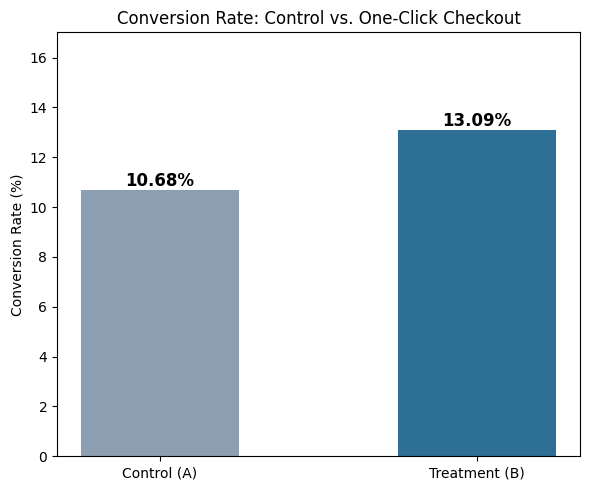

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
groups = ["Control (A)", "Treatment (B)"]
rates = [p_a * 100, p_b * 100]
colors = ["#8c9eb2", "#2e6f95"]
bars = ax.bar(groups, rates, color=colors, width=0.5)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + 0.15, f"{rate:.2f}%",
            ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("Conversion Rate (%)")
ax.set_title("Conversion Rate: Control vs. One-Click Checkout")
ax.set_ylim(0, max(rates) * 1.3)
plt.tight_layout()
plt.show()


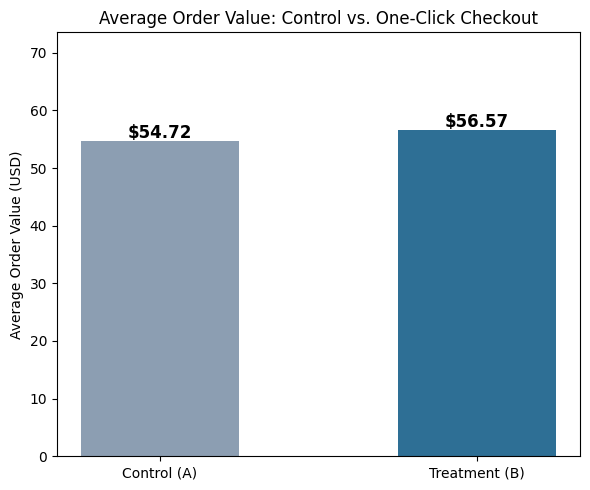

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
aov_vals = [aov_a.mean(), aov_b.mean()]
bars = ax.bar(groups, aov_vals, color=colors, width=0.5)
for bar, val in zip(bars, aov_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f"${val:.2f}",
            ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("Average Order Value (USD)")
ax.set_title("Average Order Value: Control vs. One-Click Checkout")
ax.set_ylim(0, max(aov_vals) * 1.3)
plt.tight_layout()
plt.show()


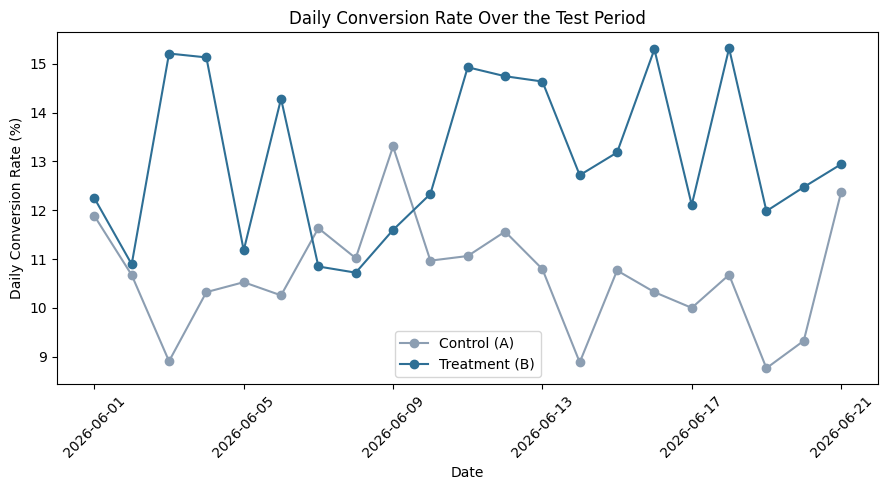

In [15]:
df["session_date"] = pd.to_datetime(df.session_timestamp).dt.date
daily = df.groupby(["session_date", "test_group"]).converted.agg(["count", "sum"]).reset_index()
daily["rate"] = daily["sum"] / daily["count"] * 100
pivot = daily.pivot(index="session_date", columns="test_group", values="rate")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pivot.index, pivot["A"], marker="o", label="Control (A)", color="#8c9eb2")
ax.plot(pivot.index, pivot["B"], marker="o", label="Treatment (B)", color="#2e6f95")
ax.set_ylabel("Daily Conversion Rate (%)")
ax.set_xlabel("Date")
ax.set_title("Daily Conversion Rate Over the Test Period")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


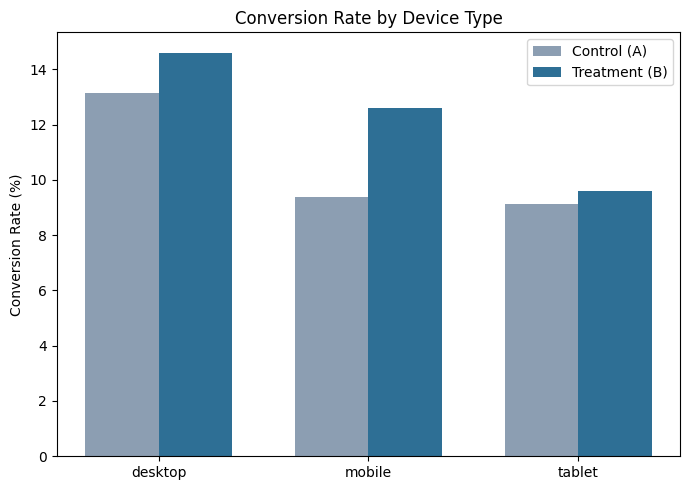

In [16]:
device_stats = df.groupby(["device_type", "test_group"]).converted.agg(["count", "sum"]).reset_index()
device_stats["rate"] = device_stats["sum"] / device_stats["count"] * 100
device_pivot = device_stats.pivot(index="device_type", columns="test_group", values="rate")

x = np.arange(len(device_pivot.index))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, device_pivot["A"], width, label="Control (A)", color="#8c9eb2")
ax.bar(x + width/2, device_pivot["B"], width, label="Treatment (B)", color="#2e6f95")
ax.set_xticks(x)
ax.set_xticklabels(device_pivot.index)
ax.set_ylabel("Conversion Rate (%)")
ax.set_title("Conversion Rate by Device Type")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Business impact and recommendation

In [17]:
rev_a = a.order_value_usd.sum()
rev_b = b.order_value_usd.sum()
rps_a = rev_a / n_a
rps_b = rev_b / n_b

print(f"Revenue per session -- Control:   ${rps_a:.3f}")
print(f"Revenue per session -- Treatment: ${rps_b:.3f}")
print(f"Estimated revenue lift per 100,000 sessions: ${(rps_b - rps_a) * 100000:,.0f}")
print()
if p_value_conv < 0.05 and diff > 0:
    print("RECOMMENDATION: Ship the One-Click Express Checkout to 100% of traffic.")
    print("The conversion lift is statistically significant and positive, with no")
    print("evidence of a negative effect on order value.")
else:
    print("RECOMMENDATION: Do not ship yet -- results are inconclusive.")


Revenue per session -- Control:   $5.845
Revenue per session -- Treatment: $7.403
Estimated revenue lift per 100,000 sessions: $155,799

RECOMMENDATION: Ship the One-Click Express Checkout to 100% of traffic.
The conversion lift is statistically significant and positive, with no
evidence of a negative effect on order value.


---
**Note:** This notebook reproduces the same results as `python/01_generate_dataset.py`,
`sql/01_analysis_queries.sql`, and `python/02_statistical_analysis.py` in this
repository. Use whichever format (notebook or standalone scripts) is more
convenient for you — they contain the same logic.
